## Adding the Dolfinx library to the colab environment

In [ ]:
!wget "https://fem-on-colab.github.io/releases/fenicsx-install-development-real.sh" -O "/tmp/fenicsx-install.sh" && bash "/tmp/fenicsx-install.sh"

## Importing the required libraries

In [1]:
from mpi4py import MPI
from dolfinx import mesh, fem, io, plot, nls, log, geometry, la
from dolfinx import cpp as _cpp
from dolfinx.nls.petsc import NewtonSolver
from dolfinx.fem.forms import extract_function_spaces
import dolfinx.fem.petsc
import ufl
import numpy as np
from petsc4py.PETSc import ScalarType
from petsc4py import PETSc
import time
import os

## Setting material properties and geometry dimensions


In [ ]:
# Material properties
E, nu = ScalarType(9800), ScalarType(0.13)	                                    #Young's modulus and Poisson's ratio
mu, lmbda, kappa = E/(2*(1 + nu)), E*nu/((1 + nu)*(1 - 2*nu)), E/(3*(1 - 2*nu))
Gc= ScalarType(0.091)	                                                            #Critical energy release rate
sts, scs= ScalarType(27), ScalarType(77)	                                        #Tensile strength and compressive strength
shs = (2/3)*sts*scs/(scs-sts)
Wts = sts**2/(2*E)
Whs = shs**2/(2*kappa)



#The regularization length
eps=0.2                                                                          
h=eps/5



delta = (1+3*h/(8*eps))**(-2) * ((sts + (1+2*np.sqrt(3))*shs)/((8+3*np.sqrt(3))*shs)) * 3*Gc/(16*Wts*eps) + (1+3*h/(8*eps))**(-1) * (2/5)
comm = MPI.COMM_WORLD
comm_rank = MPI.COMM_WORLD.rank
log.set_log_level(log.LogLevel.ERROR)

#Geometry of the single edge notch geometry
ac = 5.0                                                                          #notch length
W, L = 30.0, 5.0                                                                  #making use of symmetry

## Generating the mesh with element size $h=\frac{ϵ}{5}$

In [ ]:
domain = mesh.create_rectangle(comm = comm,points=
                             [np.array([0,0]), np.array([W,L])],n=[int(W/(32*h))
                             ,int(L/(32*h))], cell_type=mesh.CellType.triangle
                               , diagonal= mesh.DiagonalType.crossed)


def cell_criterion(x):
    """Given mesh coordinates, return if each point
    satisfies x[1]<2

    :param x: Input coordinates, shape (num_points, 3)
    :returns: Boolean array of shape (num_points, )
    """
    return (x[1]<2)

ir=0
while ir<2:
    domain.topology.create_connectivity(domain.topology.dim, domain.topology.dim)
    cells_local = np.arange(domain.topology.index_map(
        domain.topology.dim).size_local, dtype=np.int32)
    midpoints = dolfinx.mesh.compute_midpoints(
        domain, domain.topology.dim, cells_local).T
    should_refine = np.flatnonzero(cell_criterion(midpoints)).astype(np.int32)
    domain.topology.create_entities(1)
    local_edges = dolfinx.mesh.compute_incident_entities(
        domain.topology, should_refine, domain.topology.dim, 1)
    domain = dolfinx.mesh.refine(domain, local_edges)[0]
    ir+=1


def cell_criterion2(x):
    """Given mesh coordinates, return if each point
    satisfies (x[1]<2.5*eps)  & (x[0]>ac-h*8*4)

    :param x: Input coordinates, shape (num_points, 3)
    :returns: Boolean array of shape (num_points, )
    """
    return (x[1]<2.5*eps) & (x[0]>ac-h*8*4)

ir=0
while ir<3:
    domain.topology.create_connectivity(domain.topology.dim, domain.topology.dim)
    cells_local = np.arange(domain.topology.index_map(
        domain.topology.dim).size_local, dtype=np.int32)
    midpoints = dolfinx.mesh.compute_midpoints(
        domain, domain.topology.dim, cells_local).T
    should_refine = np.flatnonzero(cell_criterion2(midpoints)).astype(np.int32)
    domain.topology.create_entities(1)
    local_edges = dolfinx.mesh.compute_incident_entities(
        domain.topology, should_refine, domain.topology.dim, 1)
    domain = dolfinx.mesh.refine(domain, local_edges)[0]
    ir+=1


with dolfinx.io.XDMFFile(domain.comm, "refined_mesh.xdmf", "w") as xdmf:
    xdmf.write_mesh(domain)

## Defining the function spaces

In [4]:
# Defining the function spaces
V = fem.functionspace(domain, ("CG", 1, (domain.geometry.dim,)))                 #Function space for u
Y = fem.functionspace(domain, ("CG", 1))                                          #Function space for z

n=ufl.FacetNormal(domain)

## Creating the applied displacement on the boundary

In [5]:
class MyExpression:
    def __init__(self):
        self.t = 0.0
        self.v = 5.0

    def eval(self, x):
        values = np.zeros((1, x.shape[1]))
        values[0,:] = (1+nu)*np.sqrt(Gc)/np.sqrt(2*np.pi*E)*\
         (((x[0]-self.v*self.t)**2+L**2)**0.25)*\
          ((3-nu)/(1+nu)-np.cos(np.arctan2(L,(x[0]-self.v*self.t))))*\
          np.sin(0.5*np.arctan2(L,(x[0]-self.v*self.t)))

        return values

V_1, _ = V.sub(1).collapse()
re = MyExpression()
re.t = 0
r = fem.Function(V_1)
r.interpolate(re.eval)

## Setting the Dirichlet part of boundary conditions

In [6]:
def left(x):
    return np.isclose(x[0], 0)

def front(x):
    return np.isclose(x[0], W)

def top(x):
    return np.isclose(x[1], L)

def bottom(x):
    return (x[1]<1e-4) & (x[0]>ac - 1e-4)

def cracktip(x):
    return (x[1] < 1e-4) & (x[0] > ac - h*8*2) & (x[0] < ac+1e-4)

def righttop(x):
    return np.isclose(x[1], 0) & np.isclose(x[0], W)

def outer(x):
    return (x[1] > L/10)

fdim = domain.topology.dim -1
left_facets = mesh.locate_entities_boundary(domain, fdim, left)
front_facets = mesh.locate_entities_boundary(domain, fdim, front)
top_facets = mesh.locate_entities_boundary(domain, fdim, top)
bottom_facets = mesh.locate_entities(domain, fdim, bottom)
cracktip_facets = mesh.locate_entities(domain, fdim, cracktip)
righttop_facets = mesh.locate_entities(domain, 0, righttop)
outer_facets = mesh.locate_entities(domain, fdim, outer)


dofs_righttop = fem.locate_dofs_topological(V.sub(0), 0, righttop_facets)
dofs_bottom = fem.locate_dofs_topological(V.sub(1), fdim, bottom_facets)
dofs_top = fem.locate_dofs_topological((V.sub(1), V_1), fdim, top_facets)

dofs_outer = fem.locate_dofs_topological(Y, fdim, outer_facets)
dofs_cracktip = fem.locate_dofs_topological(Y, fdim, cracktip_facets)

bcl = fem.dirichletbc(ScalarType(0), dofs_righttop, V.sub(0))
bcb = fem.dirichletbc(ScalarType(0), dofs_bottom, V.sub(1))
bct = fem.dirichletbc(r, dofs_top, V.sub(1))
bcs = [bcl, bcb, bct]


bct_z = fem.dirichletbc(ScalarType(1), dofs_outer, Y)
bct_z2 = fem.dirichletbc(ScalarType(0), dofs_cracktip, Y)
bcs_z = [bct_z, bct_z2]


## Marking the facets and defining trial and test functions

In [7]:
marked_facets = np.hstack([front_facets, left_facets, top_facets])
marked_values = np.hstack([np.full_like(front_facets, 1),
                           np.full_like(left_facets, 2),
                           np.full_like(top_facets, 3)])
sorted_facets = np.argsort(marked_facets)
facet_tag = mesh.meshtags(domain, domain.topology.dim -1,
                          marked_facets[sorted_facets],
                          marked_values[sorted_facets])

metadata = {"quadrature_degree": 4}
ds = ufl.Measure('ds', domain=domain,
                 subdomain_data=facet_tag, metadata=metadata)
dS = ufl.Measure("dS", domain=domain, metadata=metadata)
dx = ufl.Measure("dx", domain=domain, metadata=metadata)



########################################################################
# Define functions
########################################################################
du = ufl.TrialFunction(V)                                                         # Incremental displacement
v  = ufl.TestFunction(V)                                                          # Test function for u
u  = fem.Function(V)                                                              # Displacement from previous iteration
u_inc = fem.Function(V)
dz = ufl.TrialFunction(Y)                                                         # Incremental phase field
y  = ufl.TestFunction(Y)                                                          # Test function
z  = fem.Function(Y)                                                              # Phase field from previous iteration
z_inc = fem.Function(Y)
d = len(u)                                                                        # Dimension
B  = fem.Constant(domain, (0.0, 0.0))                                             # Body force per unit volume
Tr  = fem.Constant(domain, (0.0,  0.0))                                           # Traction force on the boundary


## Setting the initial conditions

In [8]:
u.x.array[:] = 0.


z.x.array[:] = 1.


u_prev = fem.Function(V)
u_prev.x.array[:] = u.x.array
z_prev = fem.Function(Y)
z_prev.x.array[:] = z.x.array


y_dofs_top = fem.locate_dofs_topological(V.sub(1), fdim, top_facets)

## Defining a function to do an interpolation for any field for visualization purposes

In [9]:
def adjust_array_shape(input_array):
    if input_array.shape == (2,):                                                 # Check if the shape is (2,)
        adjusted_array = np.append(input_array, 0.0)                              # Append 0.0 to the array
        return adjusted_array
    else:
        return input_array
bb_tree = geometry.bb_tree(domain, domain.topology.dim)

def evaluate_function(u, x):
    """[summary]
        Helps evaluated a function at a point `x` in parallel
    Args:
        u ([dolfin.Function]): [function to be evaluated]
        x ([Union(tuple, list, numpy.ndarray)]): [point at which to evaluate function `u`]

    Returns:
        [numpy.ndarray]: [function evaluated at point `x`]
    """


    if isinstance(x, np.ndarray):
        # If x is already a NumPy array
        points0 = x
    elif isinstance(x, (tuple, list)):
        # If x is a tuple or list, convert it to a NumPy array
        points0 = np.array(x)
    else:
        # Handle the case if x is of an unsupported type
        points0 = None

    points = adjust_array_shape(points0)

    u_value = []

    cells = []
    # Find cells whose bounding-box collide with the the points
    cell_candidates = geometry.compute_collisions_points(bb_tree, points)
    # Choose one of the cells that contains the point
    colliding_cells = geometry.compute_colliding_cells(domain, cell_candidates, points)

    if len(colliding_cells.links(0)) > 0:
        u_value = u.eval(points, colliding_cells.links(0)[0])
        u_value = domain.comm.gather(u_value, root=0)
    return u_value[0]

## Defining stored energy, strain, and stress functions

In [10]:
# Stored energy, strain and stress functions in linear isotropic elasticity (plane stress)

def energy(v):
	  return mu*(ufl.inner(ufl.sym(ufl.grad(v)),ufl.sym(ufl.grad(v))) + ((nu/(1-nu))**2)*(ufl.tr(ufl.sym(ufl.grad(v))))**2 )+ 0.5*(lmbda)*(ufl.tr(ufl.sym(ufl.grad(v)))*(1-2*nu)/(1-nu))**2

def epsilon(v):
	return ufl.sym(ufl.grad(v))

def sigma(v):
	return 2.0*mu*ufl.sym(ufl.grad(v)) + (lmbda)*ufl.tr(ufl.sym(ufl.grad(v)))*(1-2*nu)/(1-nu)*ufl.Identity(len(v))

def sigmavm(sig,v):
	return ufl.sqrt(1/2*(ufl.inner(sig-1/3*ufl.tr(sig)*ufl.Identity(len(v)), sig-1/3*ufl.tr(sig)*ufl.Identity(len(v))) + (1/9)*ufl.tr(sig)**2 ))


eta = 0.0
# Stored energy density
psi1 = (z**2+eta)*(energy(u))
psi11 = energy(u)
# Total potential energy
Pi = psi1*dx
# Compute first variation of Pi (directional derivative about u in the direction of v)
R = ufl.derivative(Pi, u, v)
# Compute Jacobian of R
Jac = ufl.derivative(R, u, du)

## Defining the external force $c_{e}$ in the phase field equation

In [11]:
I1 = (z**2)*ufl.tr(sigma(u))
SQJ2 = (z**2)*sigmavm(sigma(u),u)

alpha1 = (delta*Gc)/(shs*8*eps) - (2*Whs)/(3*shs)
alpha2 = (3**0.5*(3*shs - sts)*delta*Gc)/(shs*sts*8*eps) + (2*Whs)/(3**0.5*shs) - (2*3**0.5*Wts)/(sts)

ce= alpha2*SQJ2 + alpha1*I1 - z*(1-ufl.sqrt(I1**2)/I1)*psi11

## Weak form of PDE for phase field

In [12]:
#Balance of configurational forces PDE
pen=1000*(3*Gc/8/eps)*ufl.conditional(ufl.lt(delta,1),1, delta)
Wv=pen/2*((abs(z)-z)**2 + (abs(1-z) - (1-z))**2 )*dx

R_z = y*2*z*(psi11)*dx + y*(ce)*dx + 3*delta*Gc/8*(-y/eps + 2*eps*ufl.inner(ufl.grad(z),ufl.grad(y)))*dx + ufl.derivative(Wv,z,y)

# Compute Jacobian of R_z
Jac_z = ufl.derivative(R_z, z, dz)

## Defining a class for solving nonlinear PDEs

In [13]:
class NonlinearPDEProblem:
    """Nonlinear problem class for a PDE problem using SNES interface."""

    def __init__(self, F, u, bc, J):
        """Initialize nonlinear PDE problem."""
        V = u.function_space
        du = ufl.TrialFunction(V)
        self.L = fem.form(F)
        self.a = fem.form(J)
        self.bc = bc
        self._F, self._J = None, None
        self.u = u

    def F(self, snes, x, F):
        """Assemble residual vector."""

        x.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)
        x.copy(self.u.x.petsc_vec)
        self.u.x.petsc_vec.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)

        with F.localForm() as f_local:
            f_local.set(0.0)
        fem.petsc.assemble_vector(F, self.L)
        fem.petsc.apply_lifting(F, [self.a], bcs = [self.bc], x0 = [x], alpha = -1.0)
        F.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
        fem.petsc.set_bc(F, self.bc, x, -1.0)

    def J(self, snes, x, J, P):
        """Assemble Jacobian matrix."""
        x.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)
        x.copy(self.u.x.petsc_vec)
        self.u.x.petsc_vec.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)

        J.zeroEntries()
        fem.petsc.assemble_matrix(J, self.a, bcs = self.bc)
        J.assemble()

## Setting the time step parameters


In [14]:
# time-stepping parameters
T=1
Totalsteps=500
startstepsize=1/Totalsteps
stepsize=startstepsize
t=stepsize
step=1
rtol=1e-9

## Creating Newton solvers and their customizations

In [15]:
def update(solver, dx, x):
    x.axpy(-1, dx)

# Create nonlinear problem
problem_u = NonlinearPDEProblem(R, u, bcs, Jac)

# Create Newton solver and solve


b_u_vec = fem.petsc.create_vector(V)
J_u_mat = fem.petsc.create_matrix(problem_u.a)


solver = PETSc.SNES().create()
solver.setFunction(problem_u.F, b_u_vec)
solver.setJacobian(problem_u.J, J_u_mat)


solver.setTolerances(rtol=1.0e-7, max_it=50)
solver.getKSP().setType("preonly")
solver.getKSP().setTolerances(rtol=1.0e-7)
solver.getKSP().getPC().setType("lu")


# Create nonlinear problem
problem_z = NonlinearPDEProblem(R_z, z, bcs_z, Jac_z)

# Create Newton solver and solve
b_z_vec = fem.petsc.create_vector(Y)
J_z_mat = fem.petsc.create_matrix(problem_z.a)

solver_z = PETSc.SNES().create()
solver_z.setFunction(problem_z.F, b_z_vec)
solver_z.setJacobian(problem_z.J, J_z_mat)

solver_z.setTolerances(rtol=1.0e-7, max_it=50)
solver_z.getKSP().setType("preonly")
solver_z.getKSP().setTolerances(rtol=1.0e-7)
solver_z.getKSP().getPC().setType("lu")

## Solving the problem over several time steps via a staggered scheme

In [16]:
while t-stepsize < T:

    if comm_rank==0:
        print('Step= %d' %step, 't= %f' %t, 'Stepsize= %e' %stepsize)

    re.t = t
    r.interpolate(re.eval)
    stag_iter = 1
    rnorm_stag = 1
    while stag_iter<100 and rnorm_stag > 1e-7:
        start_time=time.time()
        ##############################################################
        # PDE for u
        ##############################################################
        u_copy = u.x.petsc_vec.copy()
        u_copy.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)
        solver.solve(None, u_copy)
        u.x.scatter_forward()
        ##############################################################
        # PDE for z
        ##############################################################
        z_copy = z.x.petsc_vec.copy()
        z_copy.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)
        solver_z.solve(None, z_copy)
        z.x.scatter_forward()
        ##############################################################

        zmin = domain.comm.allreduce(np.min(z.x.array), op=MPI.MIN)


        if comm_rank==0:
            print(zmin)

        if comm_rank==0:
            print("--- %s seconds ---" % (time.time() - start_time))

        ###############################################################
        #Residual check for stag loop
        ###############################################################
        b_e = fem.petsc.assemble_vector(fem.form(-R))
        fint=b_e.copy()
        fem.petsc.set_bc(b_e, bcs, u.x.petsc_vec, -1.0)

        rnorm_stag=b_e.norm()
        stag_iter+=1

    ########### Post-processing ##############

    u_prev.x.array[:] = u.x.array
    z_prev.x.array[:] = z.x.array

    # Calculate Reaction and J-Integral

    Fx=domain.comm.allreduce(np.sum(fint[y_dofs_top]), op=MPI.SUM)
    z_x = evaluate_function(z, (ac+eps,0.0))[0]

    JI = fem.form((psi1-ufl.dot(ufl.dot(sigma(u),n),u.dx(0)))*ds(1)+
     (psi1-ufl.dot(ufl.dot(sigma(u),n),u.dx(0)))*ds(2)+
      (-ufl.dot(ufl.dot(sigma(u),n),u.dx(0)))*ds(3))

    Jintegral = domain.comm.allreduce(fem.assemble_scalar(JI), op=MPI.SUM)

    if comm_rank==0:
        print(Fx)
        print(z_x)
        with open('Surfing.txt', 'a') as rfile:
            rfile.write("%s %s %s %s\n" % (str(t), str(zmin), str(z_x), str(Fx)))
        with open('Surfing_Jintegral.txt', 'a') as rfile:
            rfile.write("%s %s\n" % (str(t), str(2*Jintegral)))

    # time stepping
    step+=1
    t+=stepsize

Step= 1 t= 0.002000 Stepsize= 2.000000e-03
0.0
--- 1.2170624732971191 seconds ---
0.0
--- 0.2825927734375 seconds ---
0.0
--- 0.2627222537994385 seconds ---
0.0
--- 0.23025965690612793 seconds ---
0.0
--- 0.22604942321777344 seconds ---
0.0
--- 0.27240490913391113 seconds ---
0.0
--- 0.22874975204467773 seconds ---
0.0
--- 0.37015247344970703 seconds ---
-73.27415062397822
0.9384733152659607
Step= 2 t= 0.004000 Stepsize= 2.000000e-03
0.0
--- -0.44385600090026855 seconds ---
0.0
--- 0.24028515815734863 seconds ---
0.0
--- 0.25814342498779297 seconds ---
0.0
--- 0.24795103073120117 seconds ---
0.0
--- 0.36441826820373535 seconds ---
-73.31048177076372
0.9383361994788652
Step= 3 t= 0.006000 Stepsize= 2.000000e-03
0.0
--- 0.2624483108520508 seconds ---
0.0
--- 0.2484598159790039 seconds ---
0.0
--- 0.23679852485656738 seconds ---
0.0
--- 0.24266576766967773 seconds ---
0.0
--- 0.406649112701416 seconds ---
-73.34688113402476
0.938198573743388
Step= 4 t= 0.008000 Stepsize= 2.000000e-03
0.0


## Results

Plot of the energy release rate as a function of time for graphite.

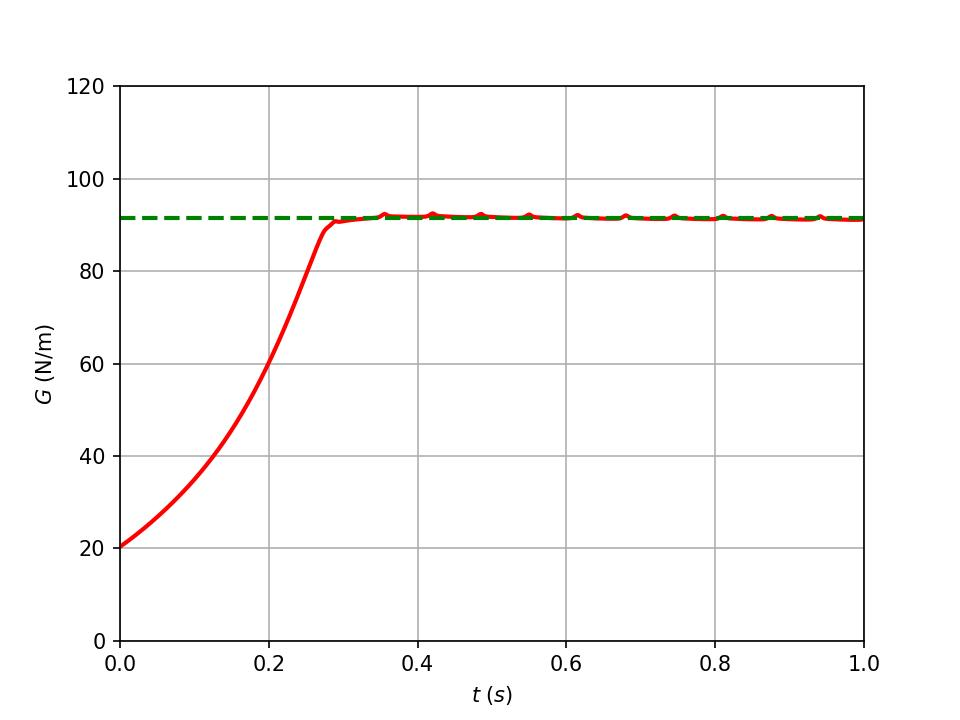